## Indlæser masterdatasættet

In [2]:
import pandas as pd
import numpy as np
import os

BASE = "/Users/PC/Documents/Speciale/Analyse/Speciale"
CLEAN_DIR = os.path.join(BASE, "clean")

master = pd.read_csv(os.path.join(CLEAN_DIR, "master_monthly.csv"))
master["month"] = pd.to_datetime(master["month"])

### Regner afkast på verdensindeks (MSCI) og globalt statsobligationsindeks

In [3]:
# ============================================================
# Indeksafkast — omregn niveauer til månedsafkast
# ============================================================
# NDDUWI = globalt aktieindeks (MSCI World net TR), LGTRTRUU = globalt statsobl.
master["eq_world_ret"]  = master["NDDUWI"].pct_change()
master["bond_world_ret"] = master["LGTRTRUU"].pct_change()

# tjek
print(master[["month","NDDUWI","eq_world_ret","LGTRTRUU","bond_world_ret"]].head(3))
print(master[["eq_world_ret","bond_world_ret"]].describe())

       month    NDDUWI  eq_world_ret  LGTRTRUU  bond_world_ret
0 2010-01-31  2680.472           NaN  190.9851             NaN
1 2010-02-28  2718.258      0.014097  191.4753        0.002567
2 2010-03-31  2886.601      0.061930  188.5217       -0.015425
       eq_world_ret  bond_world_ret
count    199.000000      199.000000
mean       0.009912        0.000566
std        0.041819        0.018515
min       -0.132343       -0.058405
25%       -0.016042       -0.009530
50%        0.014379        0.001195
75%        0.032709        0.012677
max        0.127862        0.049404


In [4]:
# ============================================================
# Valutaafkast — harmonisér quote-retning
# Mål: "afkast på at holde fremmed valuta mod USD" for alle par
# ============================================================
# EURUSD, GBPUSD: allerede "USD per fremmed valuta" → pct_change = fremmed valutas afkast mod USD
master["eur_ret"] = master["EURUSD"].pct_change()
master["gbp_ret"] = master["GBPUSD"].pct_change()

# USDJPY, USDCHF, USDDKK: "fremmed valuta per USD" → invertér, så vi får fremmed valutas afkast mod USD
master["jpy_ret"] = (1 / master["USDJPY"]).pct_change()
master["chf_ret"] = (1 / master["USDCHF"]).pct_change()
master["dkk_ret"] = (1 / master["USDDKK"]).pct_change()

# tjek: alle skal nu betyde "fremmed valuta styrkes mod USD = positivt afkast"
fx = ["eur_ret","gbp_ret","jpy_ret","chf_ret","dkk_ret"]
print(master[fx].describe().T[["mean","std","min","max"]])
print("\nKorrelationer mellem valutaafkast:")
print(master[fx].corr().round(2))

             mean       std       min       max
eur_ret -0.000597  0.024124 -0.074319  0.075237
gbp_ret -0.000553  0.023563 -0.080922  0.055157
jpy_ret -0.002508  0.026736 -0.084222  0.077062
chf_ret  0.001705  0.026119 -0.112530  0.080526
dkk_ret -0.000618  0.024062 -0.073974  0.074151

Korrelationer mellem valutaafkast:
         eur_ret  gbp_ret  jpy_ret  chf_ret  dkk_ret
eur_ret     1.00     0.70     0.33     0.71     1.00
gbp_ret     0.70     1.00     0.23     0.54     0.70
jpy_ret     0.33     0.23     1.00     0.45     0.33
chf_ret     0.71     0.54     0.45     1.00     0.71
dkk_ret     1.00     0.70     0.33     0.71     1.00


### Dollarens afdækningsegenskab over tid

In [5]:
# 1) Dollarafkast: gennemsnit af USD mod de fire hovedvalutaer.
#    Vores fx-afkast er "fremmed valuta mod USD", så USD's eget afkast er MINUS det.
master["usd_ret"] = -master[["eur_ret","jpy_ret","gbp_ret","chf_ret"]].mean(axis=1)

# 2) Rullende korrelation (36 mdr) mellem dollarafkast og verdensaktieafkast
win = 36
master["corr_usd_eq"] = master["usd_ret"].rolling(win).corr(master["eq_world_ret"])

# 3) Samme mod verdensobligationer (Campbell: dollaren hedger svagt også her)
master["corr_usd_bond"] = master["usd_ret"].rolling(win).corr(master["bond_world_ret"])

print(master[["month","corr_usd_eq","corr_usd_bond"]].dropna().head(3))
print(master[["month","corr_usd_eq","corr_usd_bond"]].dropna().tail(6))

        month  corr_usd_eq  corr_usd_bond
36 2013-01-31    -0.665702      -0.796185
37 2013-02-28    -0.661779      -0.805755
38 2013-03-31    -0.682253      -0.808694
         month  corr_usd_eq  corr_usd_bond
194 2026-03-31    -0.458857      -0.903876
195 2026-04-30    -0.476675      -0.905233
196 2026-05-31    -0.450238      -0.899797
197 2026-06-30    -0.462081      -0.899835
198 2026-07-31    -0.448545      -0.891980
199 2026-08-31    -0.434576      -0.889689


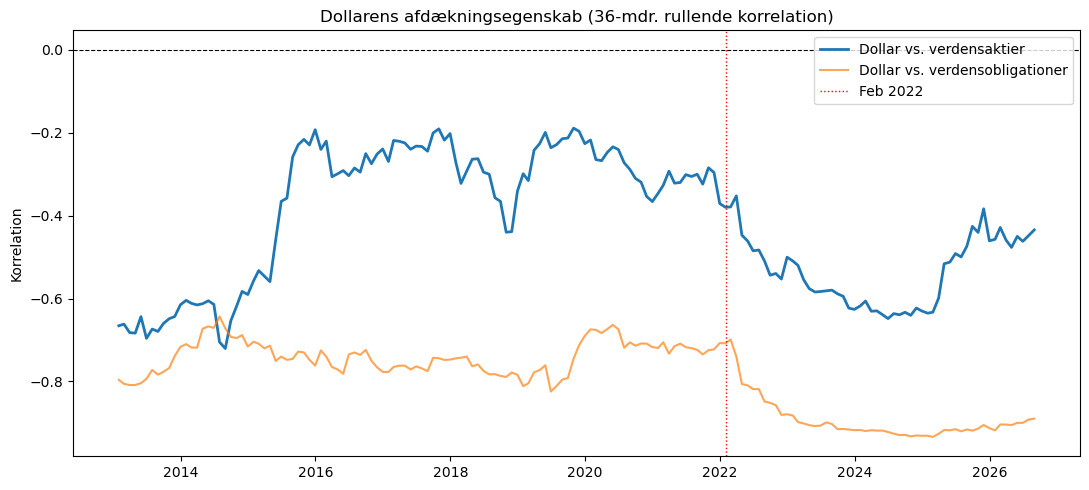

In [6]:
# PLOT: dollaren vs. verdensaktier og -obligationer
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,5))
d = master.dropna(subset=["corr_usd_eq"])
ax.plot(d["month"], d["corr_usd_eq"], label="Dollar vs. verdensaktier", lw=2)
ax.plot(d["month"], d["corr_usd_bond"], label="Dollar vs. verdensobligationer", lw=1.5, alpha=0.7)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(pd.Timestamp("2022-02-01"), color="red", lw=1, ls=":", label="Feb 2022")
ax.set_title(f"Dollarens afdækningsegenskab ({win}-mdr. rullende korrelation)")
ax.set_ylabel("Korrelation")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
import statsmodels.formula.api as smf

# standardisér GPR/TPU/VIX (så interaktionsled og niveauer er sammenlignelige og tolkbare)
for v in ["GPR","TPU","VIXCLS"]:
    master[f"{v}_z"] = (master[v] - master[v].mean()) / master[v].std()

# byg analyse-datasæt: kun rækker hvor alt det nødvendige findes
cols = ["usd_ret","eq_world_ret","GPR_z","TPU_z","VIXCLS_z","us_rf"]
reg = master.dropna(subset=cols).copy()
print("Antal observationer:", len(reg), "| periode:", reg["month"].min().date(), "->", reg["month"].max().date())

Antal observationer: 191 | periode: 2010-02-28 -> 2025-12-31


In [10]:
# Model 1 — baseline: er dollaren en hedge? (forventet negativ koeff. på aktieafkast)
m1 = smf.ols("usd_ret ~ eq_world_ret", data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

# Model 2 — svækkes hedgen med geopolitisk risiko? (interaktionsleddet er nøglen)
m2 = smf.ols("usd_ret ~ eq_world_ret * GPR_z", data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

# Model 3 — holder det, når vi kontrollerer for generel uro (VIX) og renteniveau?
m3 = smf.ols("usd_ret ~ eq_world_ret * GPR_z + eq_world_ret * VIXCLS_z + us_rf", data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

for name, m in [("M1 baseline", m1), ("M2 +GPR-interaktion", m2), ("M3 +kontroller", m3)]:
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(m.summary().tables[1])


M1 baseline
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0026      0.001      2.029      0.043    8.74e-05       0.005
eq_world_ret    -0.2207      0.035     -6.387      0.000      -0.288      -0.153

M2 +GPR-interaktion
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0026      0.001      2.079      0.038       0.000       0.005
eq_world_ret          -0.2227      0.031     -7.100      0.000      -0.284      -0.161
GPR_z                  0.0014      0.002      0.800      0.423      -0.002       0.005
eq_world_ret:GPR_z    -0.0249      0.031     -0.813      0.416      -0.085       0.035

M3 +kontroller
                            coef    std err          z      P>|z|      [0.025      0.975]
--------------

## TPU 

In [ ]:
# Newey-West (HAC) standardfejl på TPU-modellerne — robusthedstjek af hovedresultatet
m1  = smf.ols("usd_ret ~ eq_world_ret", data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
m2t = smf.ols("usd_ret ~ eq_world_ret * TPU_z", data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
m3t = smf.ols("usd_ret ~ eq_world_ret * TPU_z + eq_world_ret * VIXCLS_z + us_rf", data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

for name, m in [("M1 baseline", m1), ("M2 +TPU (HAC)", m2t), ("M3 +kontroller (HAC)", m3t)]:
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(m.summary().tables[1])


M1 baseline
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0026      0.001      2.029      0.043    8.74e-05       0.005
eq_world_ret    -0.2207      0.035     -6.387      0.000      -0.288      -0.153

M2 +TPU (HAC)
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0020      0.001      1.670      0.095      -0.000       0.004
eq_world_ret          -0.1957      0.031     -6.394      0.000      -0.256      -0.136
TPU_z                 -0.0042      0.001     -3.488      0.000      -0.007      -0.002
eq_world_ret:TPU_z     0.1213      0.023      5.187      0.000       0.075       0.167

M3 +kontroller (HAC)
                            coef    std err          z      P>|z|      [0.025      0.975]
--------------

In [13]:
reg["post2022"] = (reg["month"] >= "2022-02-01").astype(int)
m4 = smf.ols("usd_ret ~ eq_world_ret * TPU_z + eq_world_ret * post2022",
             data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(m4.summary().tables[1])

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.0011      0.001      0.760      0.447      -0.002       0.004
eq_world_ret             -0.1564      0.035     -4.469      0.000      -0.225      -0.088
TPU_z                    -0.0048      0.001     -3.386      0.001      -0.008      -0.002
eq_world_ret:TPU_z        0.1407      0.021      6.757      0.000       0.100       0.182
post2022                  0.0035      0.003      1.191      0.234      -0.002       0.009
eq_world_ret:post2022    -0.1338      0.053     -2.541      0.011      -0.237      -0.031


In [15]:
import statsmodels.formula.api as smf
import numpy as np

# ── Forbered alle variable ét sted ──────────────────────────
master["lnTPU"]      = np.log(master["TPU"])
master["lnTPU_z"]    = (master["lnTPU"] - master["lnTPU"].mean()) / master["lnTPU"].std()
master["TPU_z_lag1"] = master["TPU_z"].shift(1)

reg = master.dropna(subset=["usd_ret","eq_world_ret","TPU_z","lnTPU_z",
                            "TPU_z_lag1","VIXCLS_z","us_rf"]).copy()
reg["post2022"]   = (reg["month"] >= "2022-02-01").astype(int)
reg["post_apr25"] = (reg["month"] >= "2025-04-01").astype(int)

# ── Alle modeller samlet ────────────────────────────────────
def hac(formula):
    return smf.ols(formula, data=reg).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

modeller = {
    "M1 baseline":              hac("usd_ret ~ eq_world_ret"),
    "M2 +TPU":                  hac("usd_ret ~ eq_world_ret * TPU_z"),
    "M3 +kontroller":           hac("usd_ret ~ eq_world_ret * TPU_z + eq_world_ret * VIXCLS_z + us_rf"),
    "M4 +2022 & apr25 dummies": hac("usd_ret ~ eq_world_ret * TPU_z + eq_world_ret * post2022 + eq_world_ret * post_apr25"),
    "M5 log(TPU)":              hac("usd_ret ~ eq_world_ret * lnTPU_z + eq_world_ret * VIXCLS_z + us_rf"),
    "M6 lagget TPU":            hac("usd_ret ~ eq_world_ret * TPU_z_lag1 + eq_world_ret * VIXCLS_z + us_rf"),
}

for navn, m in modeller.items():
    print(f"\n{'='*55}\n{navn}   (n={int(m.nobs)})\n{'='*55}")
    print(m.summary().tables[1])


M1 baseline   (n=191)
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0026      0.001      2.029      0.043    8.74e-05       0.005
eq_world_ret    -0.2207      0.035     -6.387      0.000      -0.288      -0.153

M2 +TPU   (n=191)
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0020      0.001      1.670      0.095      -0.000       0.004
eq_world_ret          -0.1957      0.031     -6.394      0.000      -0.256      -0.136
TPU_z                 -0.0042      0.001     -3.488      0.000      -0.007      -0.002
eq_world_ret:TPU_z     0.1213      0.023      5.187      0.000       0.075       0.167

M3 +kontroller   (n=191)
                            coef    std err          z      P>|z|      [0.025      0.9